In [ ]:
# -----------------------------
# 1. Core Libraries
# -----------------------------
import numpy as np
import pandas as pd

# -----------------------------
# Data Splitting & Validation
# -----------------------------
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_validate

# -----------------------------
# Models
# -----------------------------
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# -----------------------------
# Evaluation Metrics
# -----------------------------
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    precision_recall_curve,
    average_precision_score
)

# -----------------------------
# Utilities
# -----------------------------
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight

# -----------------------------
# Visualization (Optional but useful)
# -----------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Warning Control
# -----------------------------
import warnings
warnings.filterwarnings("ignore")

In [ ]:
#
# 2.Data Preparation
#
df= pd.read_csv("../data/raw/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
# Dataset shape
print("Dataset shape:", df.shape)

# Check column names
print("Columns:", df.columns)

# Check missing values
df.isnull().sum().head()

Dataset shape: (284807, 31)
Columns: Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')


Time    0
V1      0
V2      0
V3      0
V4      0
dtype: int64

In [7]:
# Define target column
target_column = "Class"

# Separate features and target
X = df.drop(columns=[target_column])
y = df[target_column]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

# Class distribution
class_distribution = y.value_counts(normalize=True) * 100
print(class_distribution)

Feature matrix shape: (284807, 30)
Target vector shape: (284807,)
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


In [8]:
#
#3. Build Baseline Model
#  
# -----------------------------
# Stratified Train-Test Split
# -----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,        # 80% train, 20% test
    random_state=42,      # reproducibility
    stratify=y            # preserve class distribution
)

# -----------------------------
# Verify Split Sizes
# -----------------------------
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

# -----------------------------
# Verify Class Distribution
# -----------------------------
print("\nClass distribution in training set:")
print(y_train.value_counts(normalize=True) * 100)

print("\nClass distribution in test set:")
print(y_test.value_counts(normalize=True) * 100)


Training set shape: (227845, 30)
Test set shape: (56962, 30)

Class distribution in training set:
Class
0    99.827075
1     0.172925
Name: proportion, dtype: float64

Class distribution in test set:
Class
0    99.827955
1     0.172045
Name: proportion, dtype: float64


In [ ]:
#
#4. Build Ensemble Model
#
# -----------------------------
# Logistic Regression Pipeline
# -----------------------------

log_reg_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

# -----------------------------
# Train the Model
# -----------------------------
log_reg_pipeline.fit(X_train, y_train)


,steps,"[('scaler', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


Logistic Regression F1-Score: 0.11435832274459974
Logistic Regression AUC-PR: 0.7189705771419241


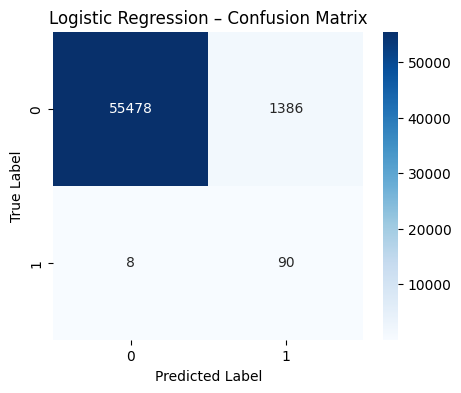

In [10]:
# Predict class labels
y_pred_lr = log_reg_pipeline.predict(X_test)

# Predict probabilities (needed for AUC-PR)
y_prob_lr = log_reg_pipeline.predict_proba(X_test)[:, 1]

f1_lr = f1_score(y_test, y_pred_lr)
print("Logistic Regression F1-Score:", f1_lr)

auc_pr_lr = average_precision_score(y_test, y_prob_lr)
print("Logistic Regression AUC-PR:", auc_pr_lr)


cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression – Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


In [ ]:
#
#5. Cross-Validation (recommended)
#
# -----------------------------
# Build Random Forest Model
# -----------------------------

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# -----------------------------
# Train the Model
# -----------------------------
rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Random Forest F1-Score: 0.8121827411167513
Random Forest AUC-PR: 0.820415842612301


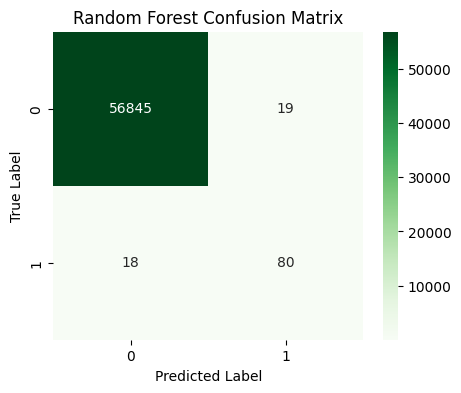

In [ ]:
# -----------------------------
# Predictions
# -----------------------------
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# -----------------------------
# Evaluation Metrics
# -----------------------------
f1_rf = f1_score(y_test, y_pred_rf)
auc_pr_rf = average_precision_score(y_test, y_prob_rf)
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Random Forest F1-Score:", f1_rf)
print("Random Forest AUC-PR:", auc_pr_rf)

# -----------------------------
# Confusion Matrix Visualization
# -----------------------------
plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [ ]:
#
#6. Model Comparison and Selection
#
# -----------------------------
# Stratified K-Fold Definition
# -----------------------------

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# -----------------------------
# Scoring Metrics
# -----------------------------

scoring = {
    "f1": "f1",
    "auc_pr": "average_precision"
}
# -----------------------------
# Logistic Regression CV
# -----------------------------

cv_lr = cross_validate(
    logistic_model,
    X,
    y,
    cv=skf,
    scoring=scoring,
    n_jobs=-1
)

print("Logistic Regression CV Results:")
print("F1-score Mean:", cv_lr["test_f1"].mean())
print("F1-score Std:", cv_lr["test_f1"].std())
print("AUC-PR Mean:", cv_lr["test_auc_pr"].mean())
print("AUC-PR Std:", cv_lr["test_auc_pr"].std())

Logistic Regression CV Results:
F1-score Mean: 0.12151579430369981
F1-score Std: 0.005904420176508043
AUC-PR Mean: 0.7420334430563456
AUC-PR Std: 0.021402181620831365


In [15]:
# -----------------------------
# Random Forest CV
# -----------------------------

cv_rf = cross_validate(
    rf_model,
    X,
    y,
    cv=skf,
    scoring=scoring,
    n_jobs=-1
)

print("\nRandom Forest CV Results:")
print("F1-score Mean:", cv_rf["test_f1"].mean())
print("F1-score Std:", cv_rf["test_f1"].std())
print("AUC-PR Mean:", cv_rf["test_auc_pr"].mean())
print("AUC-PR Std:", cv_rf["test_auc_pr"].std())


Random Forest CV Results:
F1-score Mean: 0.8363682814034877
F1-score Std: 0.025008589278598232
AUC-PR Mean: 0.823651925601687
AUC-PR Std: 0.027092036325574484


In [19]:
# -----------------------------
# Create Comparison Table
# -----------------------------

model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Test F1-Score": [f1_lr, f1_rf],
    "Test AUC-PR": [auc_pr_lr, auc_pr_rf],
    "CV F1 Mean": [
        cv_lr["test_f1"].mean(),
        cv_rf["test_f1"].mean()
    ],
    "CV F1 Std": [
        cv_lr["test_f1"].std(),
        cv_rf["test_f1"].std()
    ],
    "CV AUC-PR Mean": [
        cv_lr["test_auc_pr"].mean(),
        cv_rf["test_auc_pr"].mean()
    ],
    "CV AUC-PR Std": [
        cv_lr["test_auc_pr"].std(),
        cv_rf["test_auc_pr"].std()
    ]
})

model_comparison

,Model,Test F1-Score,Test AUC-PR,CV F1 Mean,CV F1 Std,CV AUC-PR Mean,CV AUC-PR Std
0,Logistic Regression,0.114358,0.718971,0.121516,0.005904,0.742033,0.021402
1,Random Forest,0.812183,0.820416,0.836368,0.025009,0.823652,0.027092


In [20]:
# -----------------------------
# Select Best Model
# -----------------------------

best_model = rf_model if auc_pr_rf > auc_pr_lr else logistic_model
print("Selected Best Model:", type(best_model).__name__)

Selected Best Model: RandomForestClassifier


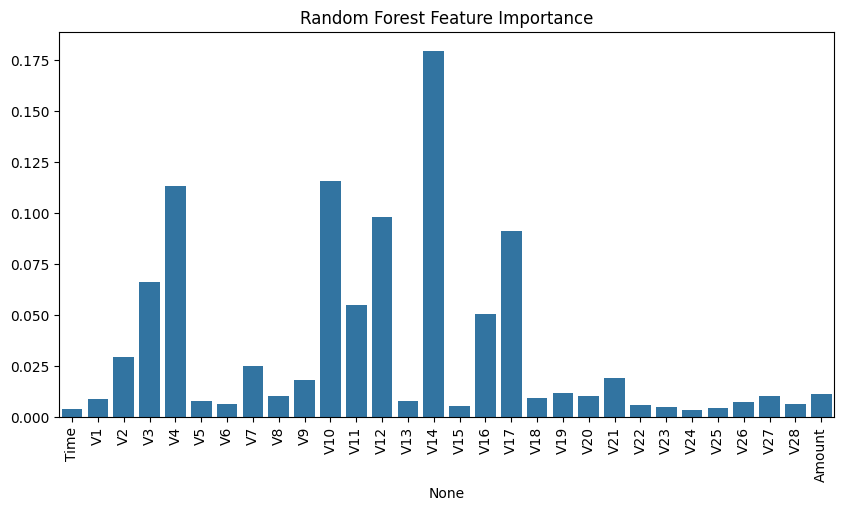

In [21]:
# 
importances = rf_model.feature_importances_
plt.figure(figsize=(10,5))
sns.barplot(x=X.columns, y=importances)  # X.columns = all feature names
plt.title("Random Forest Feature Importance")
plt.xticks(rotation=90)
plt.show()


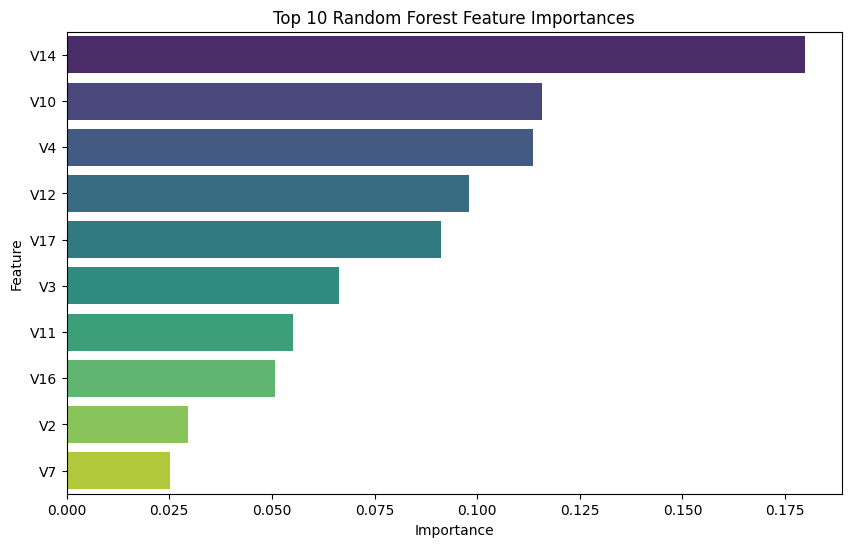

In [22]:
# -----------------------------
# Random Forest Feature Importance – Top 10
# -----------------------------

importances = rf_model.feature_importances_
feature_names = X.columns

# Create a DataFrame for easier sorting
feat_importances = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# Sort by importance descending
feat_importances = feat_importances.sort_values(by="Importance", ascending=False)

# Take top 10
top10 = feat_importances.head(10)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=top10, palette="viridis")
plt.title("Top 10 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()
